# 5.4)

Since the model where each observation has the same mean is a nested model of the saturated model, it follows from davison p.472 that the deviance statistic is asymptotically chi-squared with degrees of freedom equal to the difference in the number of parameters between the two models. In this case, the saturated model has n parameters (one for each observation), while the model with a common mean has 1 parameter (the common mean). Therefore, the deviance statistic is asymptotically chi-squared with n - 1 degrees of freedom.

However, we see that for low values of lambda, we will draw many zeros, which will make the sample mean very small. This will lead to a large observed deviance, which will not be well approximated by the chi-squared distribution. As lambda increases, we will draw fewer zeros, and the sample mean will be larger, leading to a smaller observed deviance, which will be better approximated by the chi-squared distribution.

In [36]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2
import statsmodels.api as sm

ns = [10, 100 ,1000]
lams = [1, 10, 100]
N = 1000

def deviance(n, lam):
    y = np.random.poisson(lam= lam, size=n)
    ybar = np.mean(y)
    # Note that y[j] = 0 has no contribution to deviance, thus
    y = y[y > 0]
    return 2 * np.sum(y*np.log(y / ybar))

D = {}

for n in ns:
    for lam in lams:

        D[n, lam] = [deviance(n, lam) for _ in range(N)]



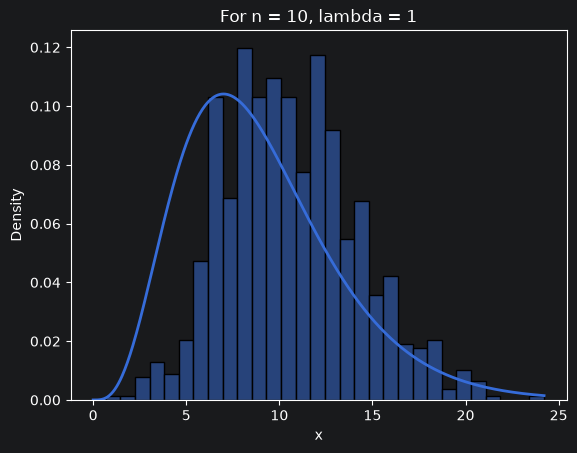

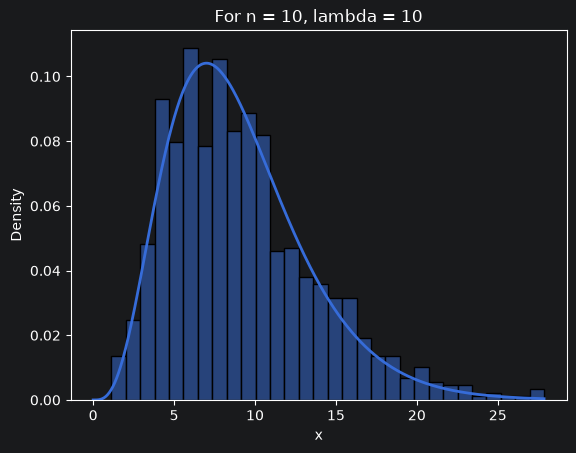

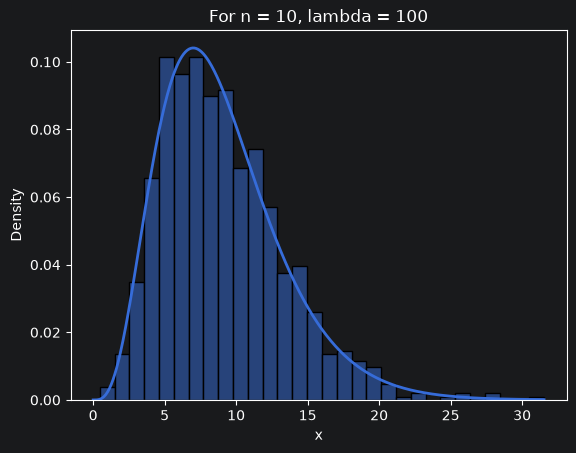

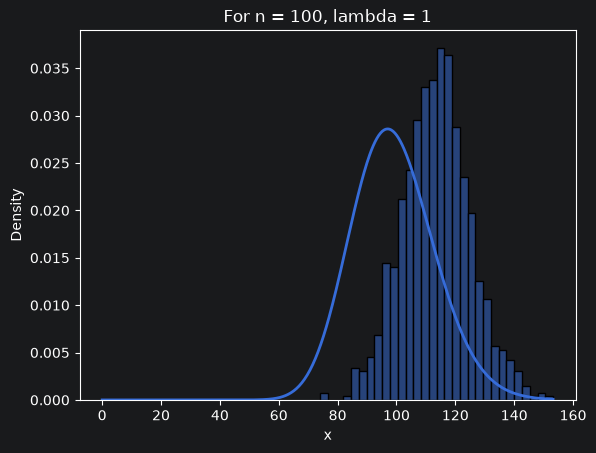

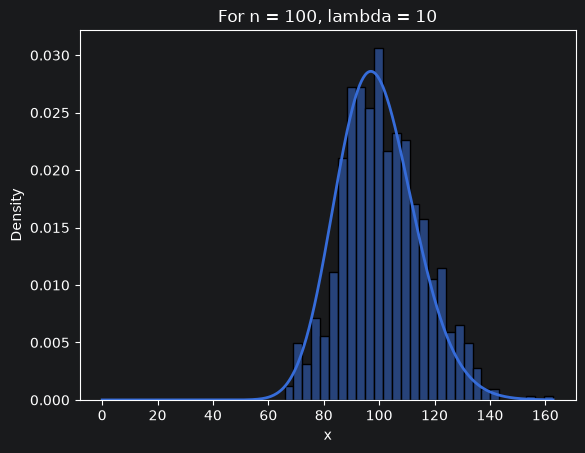

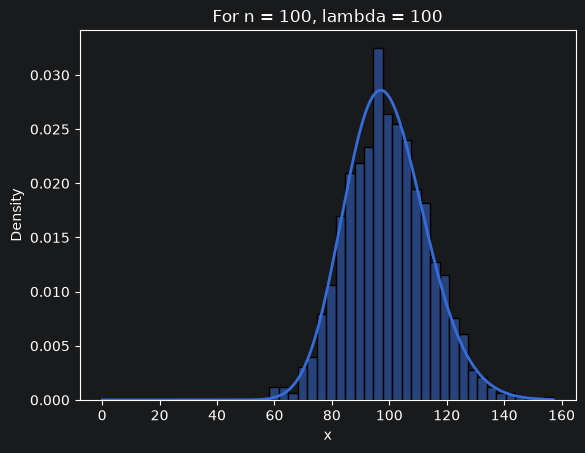

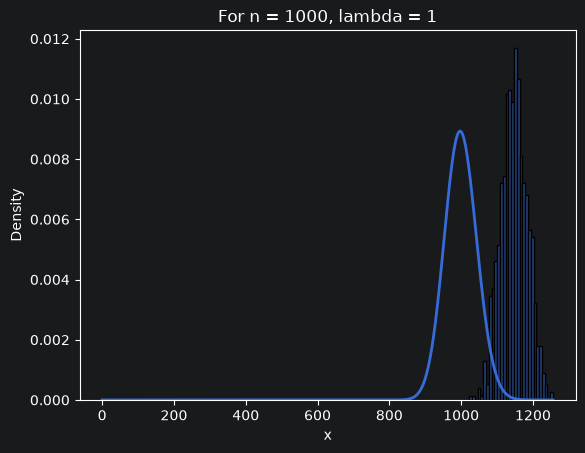

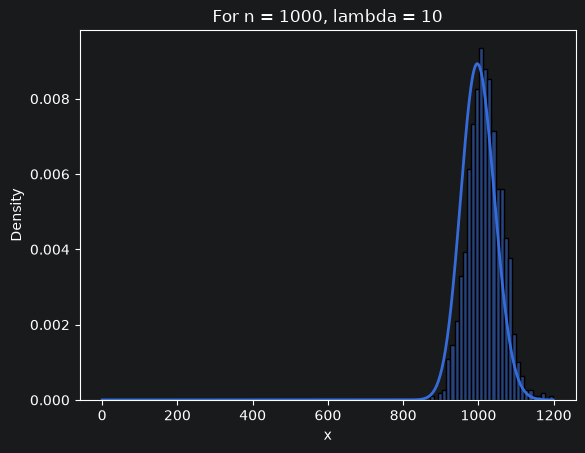

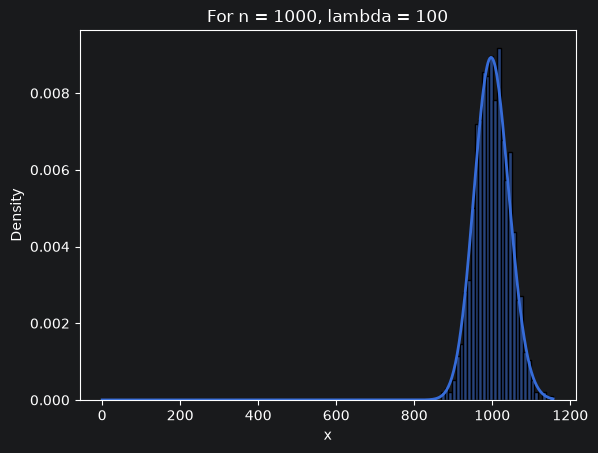

In [37]:
from IPython.display import clear_output
for n in ns:
    for lam in lams:

        data = D[n, lam]
        df = n - 1

        # Clear the previous plot from the notebook
        #clear_output(wait=True)

        fig, ax = plt.subplots()

        # Histogram
        sns.histplot(
            data,
            bins=30,
            stat="density",
            alpha=0.5,
            ax=ax
        )

        # Theoretical PDF
        x = np.linspace(0, max(data), 500)
        pdf = chi2.pdf(x, df=df)

        ax.plot(x, pdf, linewidth=2)

        ax.set_title(f"For n = {n}, lambda = {lam}")
        ax.set_xlabel("x")
        ax.set_ylabel("Density")

        plt.show()

        #input("Press Enter to continue...")
        #plt.close(fig)

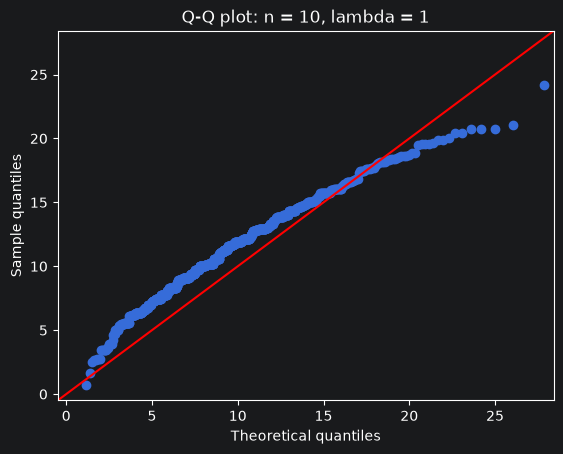

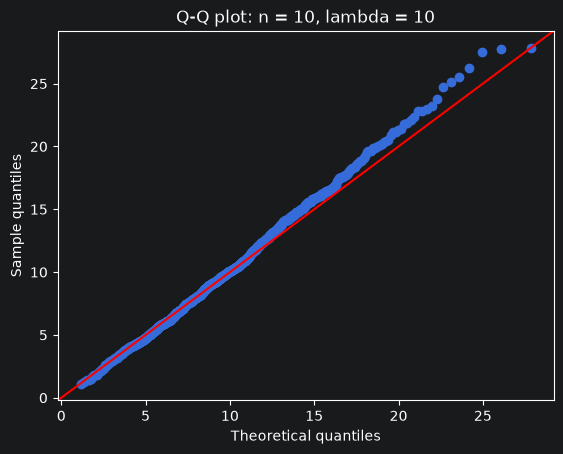

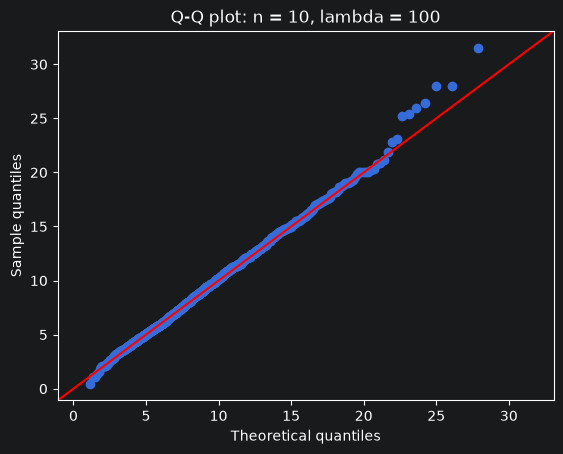

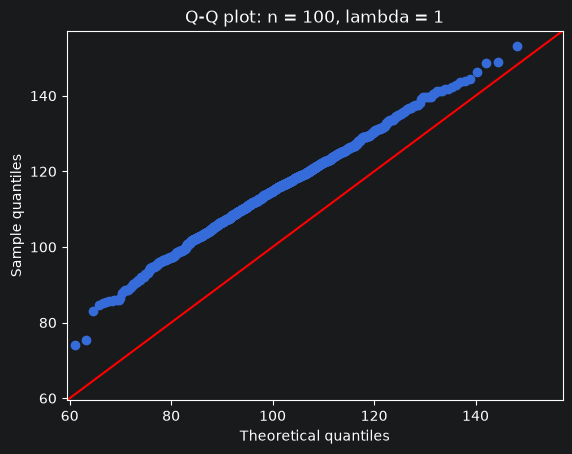

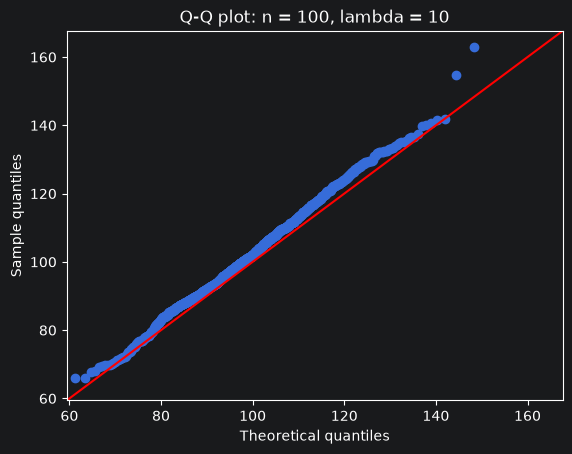

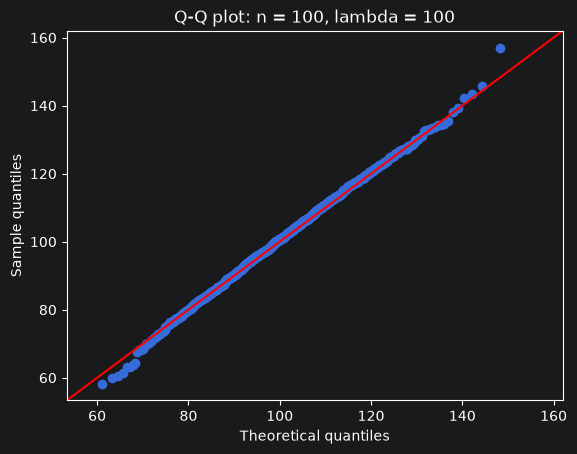

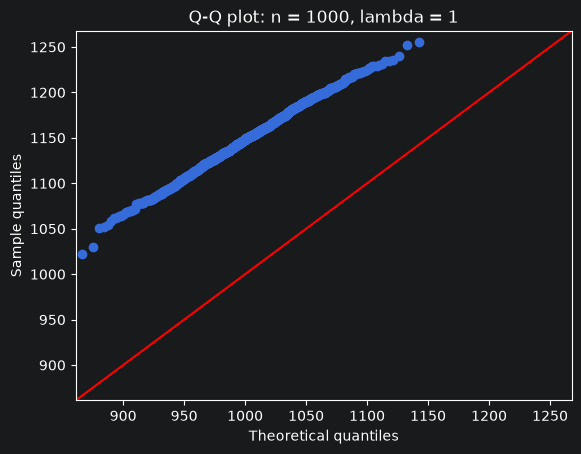

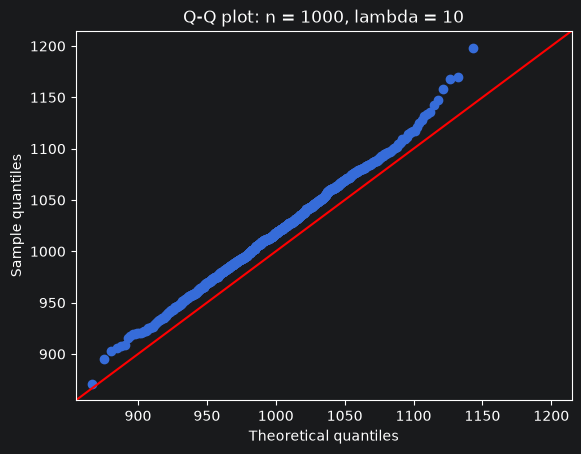

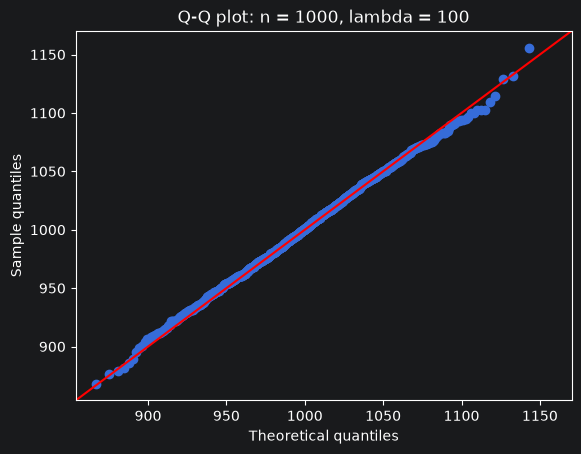

In [38]:
for n in ns:
    for lam in lams:

        data = np.array(D[n, lam])
        df = n - 1

        #clear_output(wait=True)

        fig, ax = plt.subplots()

        sm.qqplot(
            data,
            dist=chi2,
            distargs=(df,),
            line="45",
            ax=ax
        )

        ax.set_title(f"Q-Q plot: n = {n}, lambda = {lam}")
        ax.set_xlabel("Theoretical quantiles")
        ax.set_ylabel("Sample quantiles")

        plt.show()